# Week 5 - Final Project: Integrated Findings and Evidence for Recommendations

**Dataset:** IBM Telco Customer Churn (7,043 customers), acquired and cleaned in Week 1.

This notebook runs `src/07_final_analysis.py`, the final stage of the project pipeline.
It reads the saved results of stages 01-06 (EDA, visual story, hypothesis tests and the
churn model), so run `python src/run_all.py` first on a fresh checkout. The code cells
are taken directly from `src/`.


In [1]:
import sys
sys.path.insert(0, "../src")  # make the project modules in src/ importable
%config InlineBackend.figure_format = 'retina'

## Week 5 - Integrated analysis and evidence for recommendations

This script does not repeat the earlier analyses. It reads their saved results
(`outputs/results/*.json`, `outputs/tables/*.csv`) and the cleaned data, and
answers three integration questions:

1. Does each churn driver hold up across the EDA (Week 1), the visual story
   (Week 2), the statistical tests (Week 3) and the model (Week 4)?
2. How well does the model concentrate churners when customers are ranked by
   risk? (held-out test set only)
3. How large are the customer groups that the recommendations would target?

Everything here is descriptive or predictive. None of it measures the effect of
an intervention.

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter

from config import RESULTS_DIR, TABLE_DIR
from data_utils import load_clean_data
from plot_style import CHURN_COLOR, INK, MUTED_INK, ORDINAL_BLUES, RETAINED_COLOR, apply_style, save_figure

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)
apply_style()


def load(name):
    with open(RESULTS_DIR / name) as f:
        return json.load(f)


eda, story = load("eda_summary.json"), load("visual_story_summary.json")
stat, model = load("statistical_results.json"), load("model_results.json")
df = load_clean_data()
predictions = pd.read_csv(TABLE_DIR / "test_predictions.csv")
final = {}

### 1. The problem in numbers

In [3]:
churned = df["churn_flag"] == 1
overview = pd.Series({
    "customers": len(df),
    "churned customers": int(churned.sum()),
    "churn rate (%)": round(churned.mean() * 100, 2),
    "monthly charges, all customers (USD)": round(df["MonthlyCharges"].sum(), 2),
    "monthly charges of churned customers (USD)": round(df.loc[churned, "MonthlyCharges"].sum(), 2),
    "share of monthly charges from churned customers (%)":
        round(df.loc[churned, "MonthlyCharges"].sum() / df["MonthlyCharges"].sum() * 100, 2),
})
display(overview.to_frame("value"))
final["overview"] = overview.to_dict()

,value
customers,7043.00
churned customers,1869.00
churn rate (%),26.54
"monthly charges, all customers (USD)",456116.60
monthly charges of churned customers (USD),139130.85
share of monthly charges from churned customers (%),30.50


### 2. Evidence matrix: does each driver hold up across the four weeks?

In [4]:
rates = eda["churn_rate_by_category"]
A, cmh, B, C = stat["A"], stat["A_cmh"], stat["B"], {r["add_on"]: r for r in stat["C"]}
coef = {r["feature"]: r["odds_ratio"] for r in model["coefficients"]}
tenure_rates = eda["tenure_band_churn"]

evidence = pd.DataFrame([
    {"driver": "Contract type",
     "week1_eda": f"M2M {rates['Contract']['Month-to-month']['churn_rate_pct']:.1f}% vs two-year "
                  f"{rates['Contract']['Two year']['churn_rate_pct']:.1f}%",
     "week2_story": "M2M highest in every tenure band",
     "week3_test": f"chi2 p={A['p_value']:.1e}, V={A['cramers_v']:.2f}; tenure-adjusted OR {cmh['pooled_or']:.2f}",
     "week4_model": f"OR two-year {coef['Contract_Two year']:.2f}, one-year {coef['Contract_One year']:.2f} (vs M2M)",
     "reading": "Consistent and strong in all four weeks"},
    {"driver": "Tenure (early months)",
     "week1_eda": f"0-12 m {tenure_rates['0-12']['churn_rate_pct']:.1f}% vs 61-72 m "
                  f"{tenure_rates['61-72']['churn_rate_pct']:.1f}%",
     "week2_story": f"{story['v1']['share_of_churners_in_first_12_months_pct']:.1f}% of churners left in year 1",
     "week3_test": f"contract effect largest in year 1 (OR {cmh['strata'][0]['odds_ratio']:.1f})",
     "week4_model": f"OR {coef['log_tenure']:.2f} per SD of log_tenure",
     "reading": "Consistent and strong"},
    {"driver": "Fibre optic internet",
     "week1_eda": f"fibre {rates['InternetService']['Fiber optic']['churn_rate_pct']:.1f}% vs DSL "
                  f"{rates['InternetService']['DSL']['churn_rate_pct']:.1f}%",
     "week2_story": "highest churn despite leavers paying less within service",
     "week3_test": "within-service charge gaps negative (all p<0.001)",
     "week4_model": f"OR {coef['InternetService_Fiber optic']:.2f} vs DSL",
     "reading": "Consistent; reason not visible in data"},
    {"driver": "No security / tech support",
     "week1_eda": f"no tech support {rates['TechSupport']['No']['churn_rate_pct']:.1f}% vs "
                  f"{rates['TechSupport']['Yes']['churn_rate_pct']:.1f}%",
     "week2_story": "largest add-on gaps (about 27 points)",
     "week3_test": f"diff {C['OnlineSecurity']['difference_pp']:.1f} pp / {C['TechSupport']['difference_pp']:.1f} pp (p<0.001)",
     "week4_model": f"OR {coef['OnlineSecurity_Yes']:.2f} / {coef['TechSupport_Yes']:.2f} with add-on",
     "reading": "Consistent; smaller once other factors held constant"},
    {"driver": "Electronic-check payment",
     "week1_eda": f"{rates['PaymentMethod']['Electronic check']['churn_rate_pct']:.1f}% vs 15.2-19.1% others",
     "week2_story": "higher within every contract type",
     "week3_test": "not tested formally",
     "week4_model": f"OR {coef['PaymentMethod_Electronic check']:.2f} vs bank transfer",
     "reading": "Consistent marker; weaker than contract"},
    {"driver": "Monthly charges",
     "week1_eda": f"churner median USD {eda['numeric_by_churn']['Yes']['MonthlyCharges']['median']:.2f} vs "
                  f"{eda['numeric_by_churn']['No']['MonthlyCharges']['median']:.2f}",
     "week2_story": "reverses within each internet service",
     "week3_test": f"+USD {B['mean_difference']:.2f} overall (g={B['hedges_g']:.2f}); negative within services",
     "week4_model": f"OR {coef['MonthlyCharges']:.2f} per SD (entangled with services)",
     "reading": "Not a reliable driver on its own"},
])

In [5]:
# One row per driver: the evidence from each week, side by side
display(evidence)
evidence.to_csv(TABLE_DIR / "evidence_matrix.csv", index=False)
final["evidence_matrix"] = evidence.to_dict("records")

,driver,week1_eda,week2_story,week3_test,week4_model,reading
0,Contract type,M2M 42.7% vs two-year 2.8%,M2M highest in every tenure band,"chi2 p=5.9e-258, V=0.41; tenure-adjusted OR 7.11","OR two-year 0.20, one-year 0.49 (vs M2M)",Consistent and strong in all four weeks
1,Tenure (early months),0-12 m 47.4% vs 61-72 m 6.6%,55.5% of churners left in year 1,contract effect largest in year 1 (OR 14.5),OR 0.44 per SD of log_tenure,Consistent and strong
2,Fibre optic internet,fibre 41.9% vs DSL 19.0%,highest churn despite leavers paying less within service,within-service charge gaps negative (all p<0.001),OR 3.04 vs DSL,Consistent; reason not visible in data
3,No security / tech support,no tech support 41.6% vs 15.2%,largest add-on gaps (about 27 points),diff 27.2 pp / 26.5 pp (p<0.001),OR 0.73 / 0.77 with add-on,Consistent; smaller once other factors held constant
4,Electronic-check payment,45.3% vs 15.2-19.1% others,higher within every contract type,not tested formally,OR 1.40 vs bank transfer,Consistent marker; weaker than contract
5,Monthly charges,churner median USD 79.65 vs 64.43,reverses within each internet service,+USD 13.18 overall (g=0.45); negative within services,OR 0.81 per SD (entangled with services),Not a reliable driver on its own


### 3. Ranking customers by predicted risk (held-out test set)

If a retention team could contact only a fraction of customers, how many of the
churners would the model's ranking reach? The test customers were never used
to train the model or choose its threshold.

In [6]:
ranked = predictions.sort_values("probability", ascending=False).reset_index(drop=True)
ranked["decile"] = pd.qcut(ranked.index, 10, labels=range(1, 11))
total_churners = ranked["actual"].sum()
base_rate = ranked["actual"].mean()

deciles = ranked.groupby("decile", observed=True).agg(customers=("actual", "size"), churners=("actual", "sum"),
                                                      mean_probability=("probability", "mean"))
deciles["churn_rate"] = deciles["churners"] / deciles["customers"]
deciles["lift"] = deciles["churn_rate"] / base_rate
deciles["cumulative_share_of_churners"] = deciles["churners"].cumsum() / total_churners
display(deciles.round(3))

gains = {}
for share in (0.10, 0.20, 0.30, 0.50):
    top = ranked.iloc[: int(round(share * len(ranked)))]
    gains[f"top_{int(share * 100)}pct"] = {"customers": len(top), "churners": int(top["actual"].sum()),
                                           "share_of_churners": round(top["actual"].sum() / total_churners, 4),
                                           "precision": round(top["actual"].mean(), 4)}
display(pd.DataFrame(gains).T)
deciles.round(4).to_csv(TABLE_DIR / "risk_deciles_test_set.csv")
final["test_base_rate"] = round(float(base_rate), 4)
final["test_customers"] = len(ranked)
final["test_churners"] = int(total_churners)
final["gains"] = gains
final["deciles"] = deciles.round(4).reset_index().to_dict("records")

,customers,churners,mean_probability,churn_rate,lift,cumulative_share_of_churners
decile,,,,,,
1,141,108,0.772,0.766,2.886,0.289
2,141,84,0.585,0.596,2.244,0.513
3,141,55,0.455,0.390,1.470,0.660
4,141,44,0.335,0.312,1.176,0.778
5,141,36,0.232,0.255,0.962,0.874
6,140,24,0.144,0.171,0.646,0.939
7,141,15,0.082,0.106,0.401,0.979
8,141,5,0.044,0.035,0.134,0.992
9,141,2,0.021,0.014,0.053,0.997


,customers,churners,share_of_churners,precision
top_10pct,141.0,108.0,0.2888,0.7660
top_20pct,282.0,192.0,0.5134,0.6809
top_30pct,423.0,247.0,0.6604,0.5839
top_50pct,704.0,327.0,0.8743,0.4645


Saved figure: outputs/figures/fig5_1_gains_and_risk_deciles.png


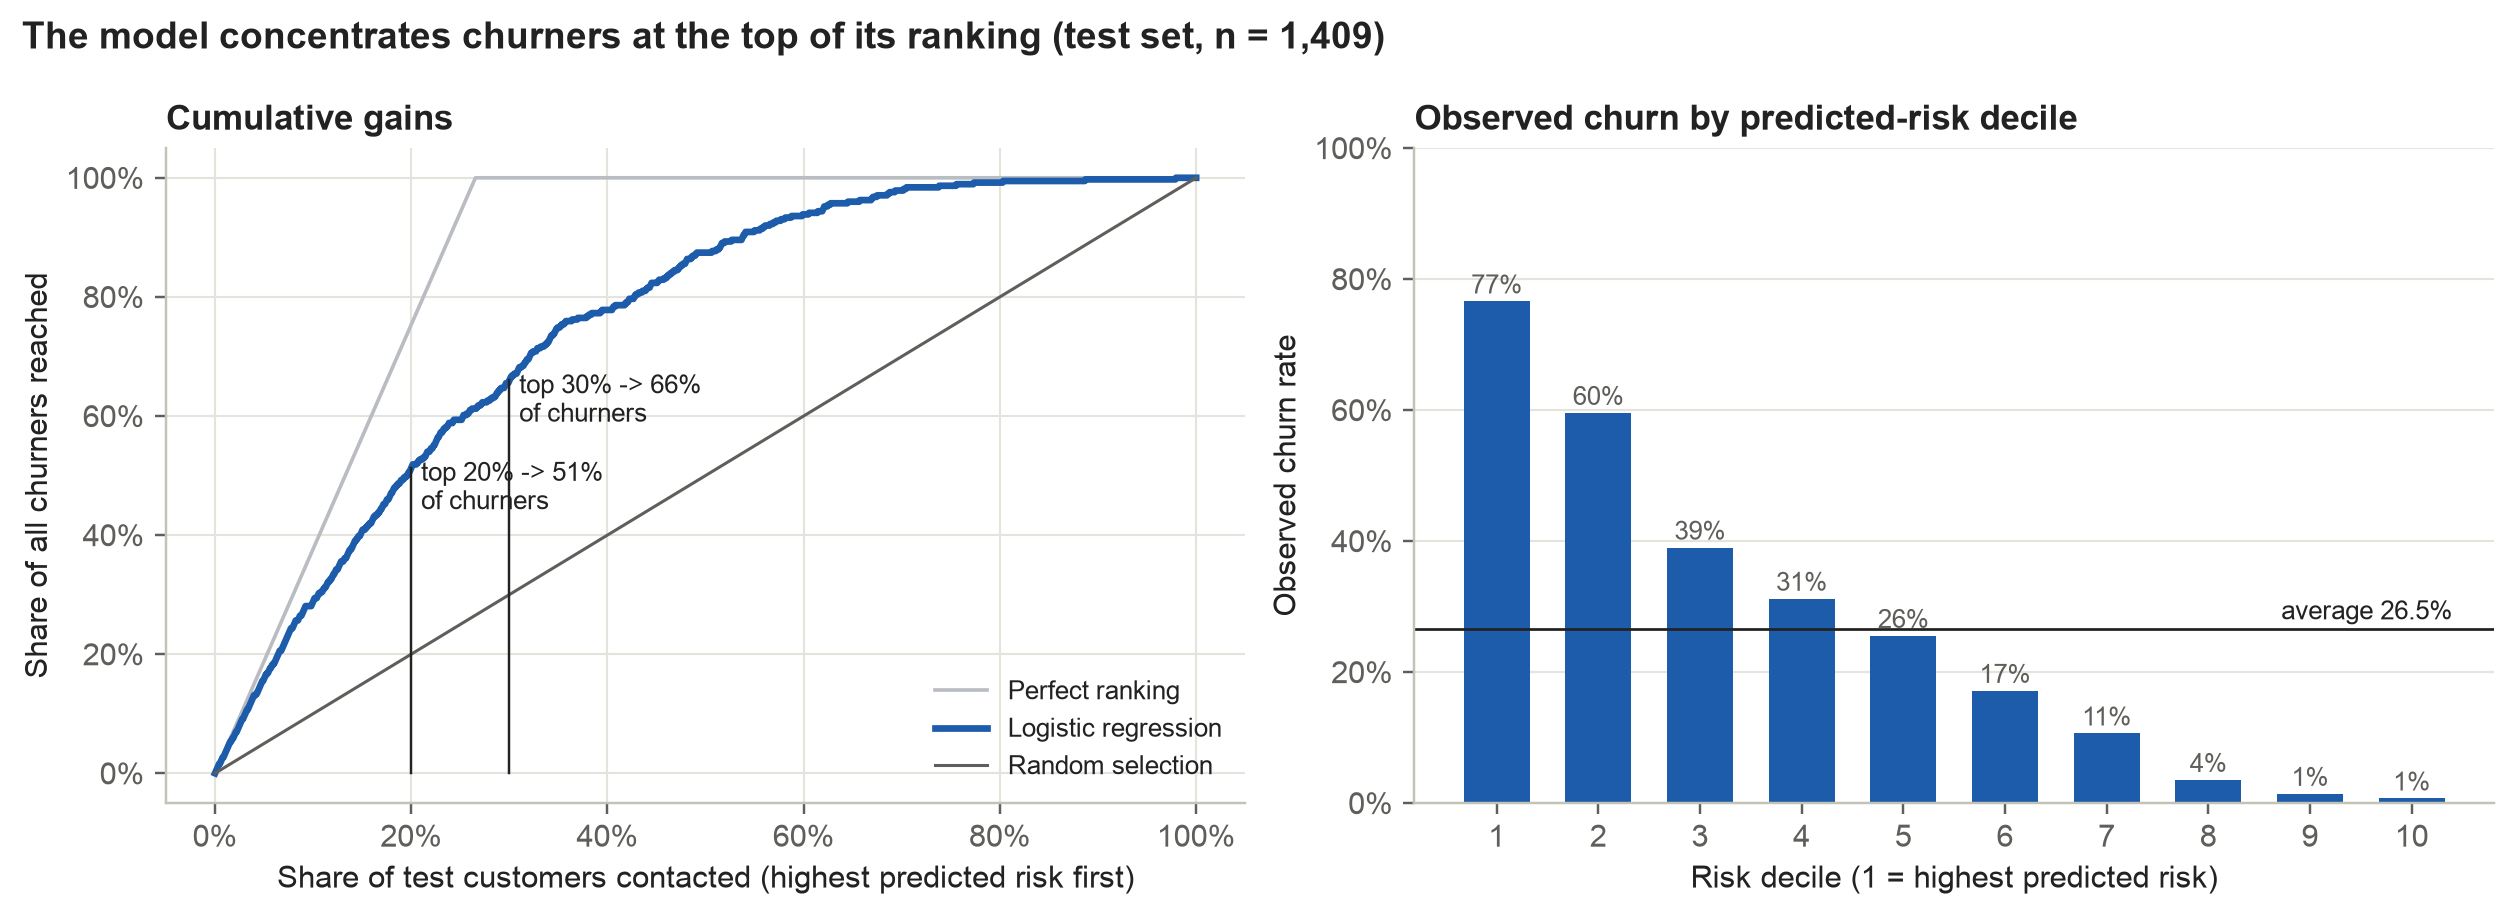

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
ax = axes[0]
contacted = np.arange(0, len(ranked) + 1) / len(ranked)
captured = np.concatenate([[0], ranked["actual"].cumsum().to_numpy() / total_churners])
perfect = np.minimum(contacted / base_rate, 1)
ax.plot(contacted, perfect, color=RETAINED_COLOR, linewidth=1.2, label="Perfect ranking")
ax.plot(contacted, captured, color=CHURN_COLOR, linewidth=2.2, label="Logistic regression")
ax.plot([0, 1], [0, 1], color=MUTED_INK, linewidth=1, label="Random selection")
for share in (0.2, 0.3):
    g = gains[f"top_{int(share * 100)}pct"]["share_of_churners"]
    ax.plot([share, share], [0, g], color=INK, linewidth=0.8)
    ax.text(share + 0.01, g - 0.07, f"top {share:.0%} -> {g:.0%}\nof churners", fontsize=8.5, color=INK)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Share of test customers contacted (highest predicted risk first)")
ax.set_ylabel("Share of all churners reached")
ax.set_title("Cumulative gains")
ax.legend(loc="lower right", fontsize=8.5)
ax = axes[1]
ax.bar(deciles.index.astype(int), deciles["churn_rate"], color=CHURN_COLOR, width=0.65)
ax.axhline(base_rate, color=INK, linewidth=0.9)
ax.text(10.4, base_rate + 0.015, f"average {base_rate:.1%}", ha="right", fontsize=8.5)
for x_pos, rate in zip(deciles.index.astype(int), deciles["churn_rate"]):
    ax.text(x_pos, rate + 0.012, f"{rate:.0%}", ha="center", fontsize=8.5, color=MUTED_INK)
ax.set_xticks(range(1, 11))
ax.set_xlabel("Risk decile (1 = highest predicted risk)")
ax.set_ylabel("Observed churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1)
ax.set_title("Observed churn by predicted-risk decile")
ax.grid(axis="x", visible=False)
fig.suptitle(f"The model concentrates churners at the top of its ranking (test set, n = {len(ranked):,})",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, "fig5_1_gains_and_risk_deciles.png")

### 4. Risk tiers using the Week 4 threshold (test set)

In [8]:
threshold = model["threshold"]["chosen"]
ranked["tier"] = pd.cut(ranked["probability"], bins=[-0.01, threshold, 0.5, 1.0],
                        labels=[f"Low (< {threshold:.2f})", f"Medium ({threshold:.2f}-0.50)", "High (>= 0.50)"],
                        right=False)
tiers = ranked.groupby("tier", observed=True).agg(customers=("actual", "size"), churners=("actual", "sum"))
tiers["share_of_customers"] = tiers["customers"] / len(ranked)
tiers["churn_rate"] = tiers["churners"] / tiers["customers"]
tiers["share_of_churners"] = tiers["churners"] / total_churners
tiers = tiers.iloc[::-1]
display(tiers.round(3))
tiers.round(4).to_csv(TABLE_DIR / "risk_tiers_test_set.csv")
final["risk_tiers"] = tiers.round(4).reset_index().astype({"tier": str}).to_dict("records")

,customers,churners,share_of_customers,churn_rate,share_of_churners
tier,,,,,
High (>= 0.50),295,197,0.209,0.668,0.527
Medium (0.34-0.50),185,75,0.131,0.405,0.201
Low (< 0.34),929,102,0.659,0.110,0.273


### 5. Sizing the groups behind the recommendations (all 7,043 customers)

Segments come from earlier findings. They overlap, so their shares should not
be added together.

In [9]:
internet = df["InternetService"] != "No"
segments = {
    "Month-to-month, fibre, electronic check": (df["Contract"] == "Month-to-month")
                                                & (df["InternetService"] == "Fiber optic")
                                                & (df["PaymentMethod"] == "Electronic check"),
    "Month-to-month, first 12 months": (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12),
    "Internet, no security and no tech support": internet & (df["OnlineSecurity"] == "No")
                                                 & (df["TechSupport"] == "No"),
    "Fibre optic (all)": df["InternetService"] == "Fiber optic",
    "One- or two-year contract": df["Contract"] != "Month-to-month",
}
total_charges_churned = df.loc[churned, "MonthlyCharges"].sum()
segment_rows = []
for name, mask in segments.items():
    segment_rows.append({
        "segment": name, "customers": int(mask.sum()), "share_of_customers": mask.mean(),
        "churners": int((mask & churned).sum()), "churn_rate": df.loc[mask, "churn_flag"].mean(),
        "share_of_churners": (mask & churned).sum() / churned.sum(),
        "share_of_churned_monthly_charges": df.loc[mask & churned, "MonthlyCharges"].sum() / total_charges_churned,
    })
segment_table = pd.DataFrame(segment_rows)
display(segment_table.round(3))
priority = list(segments)[:3]
covered = np.logical_or.reduce([segments[name] for name in priority])
print(f"Churners in at least one of the three priority segments: {(covered & churned).sum():,} of "
      f"{churned.sum():,} ({(covered & churned).sum() / churned.sum():.1%}); "
      f"these segments contain {covered.mean():.1%} of all customers")
segment_table.to_csv(TABLE_DIR / "priority_segments.csv", index=False)
final["segments"] = segment_table.round(4).to_dict("records")
final["priority_union"] = {"customers": int(covered.sum()), "share_of_customers": round(float(covered.mean()), 4),
                           "churners": int((covered & churned).sum()),
                           "share_of_churners": round(float((covered & churned).sum() / churned.sum()), 4)}

,segment,customers,share_of_customers,churners,churn_rate,share_of_churners,share_of_churned_monthly_charges
0,"Month-to-month, fibre, electronic check",1307,0.186,789,0.604,0.422,0.491
1,"Month-to-month, first 12 months",1994,0.283,1024,0.514,0.548,0.491
2,"Internet, no security and no tech support",2553,0.362,1250,0.490,0.669,0.684
3,Fibre optic (all),3096,0.440,1297,0.419,0.694,0.822
4,One- or two-year contract,3168,0.450,214,0.068,0.114,0.131


Churners in at least one of the three priority segments: 1,602 of 1,869 (85.7%); these segments contain 51.0% of all customers


Saved figure: outputs/figures/fig5_2_priority_segments.png


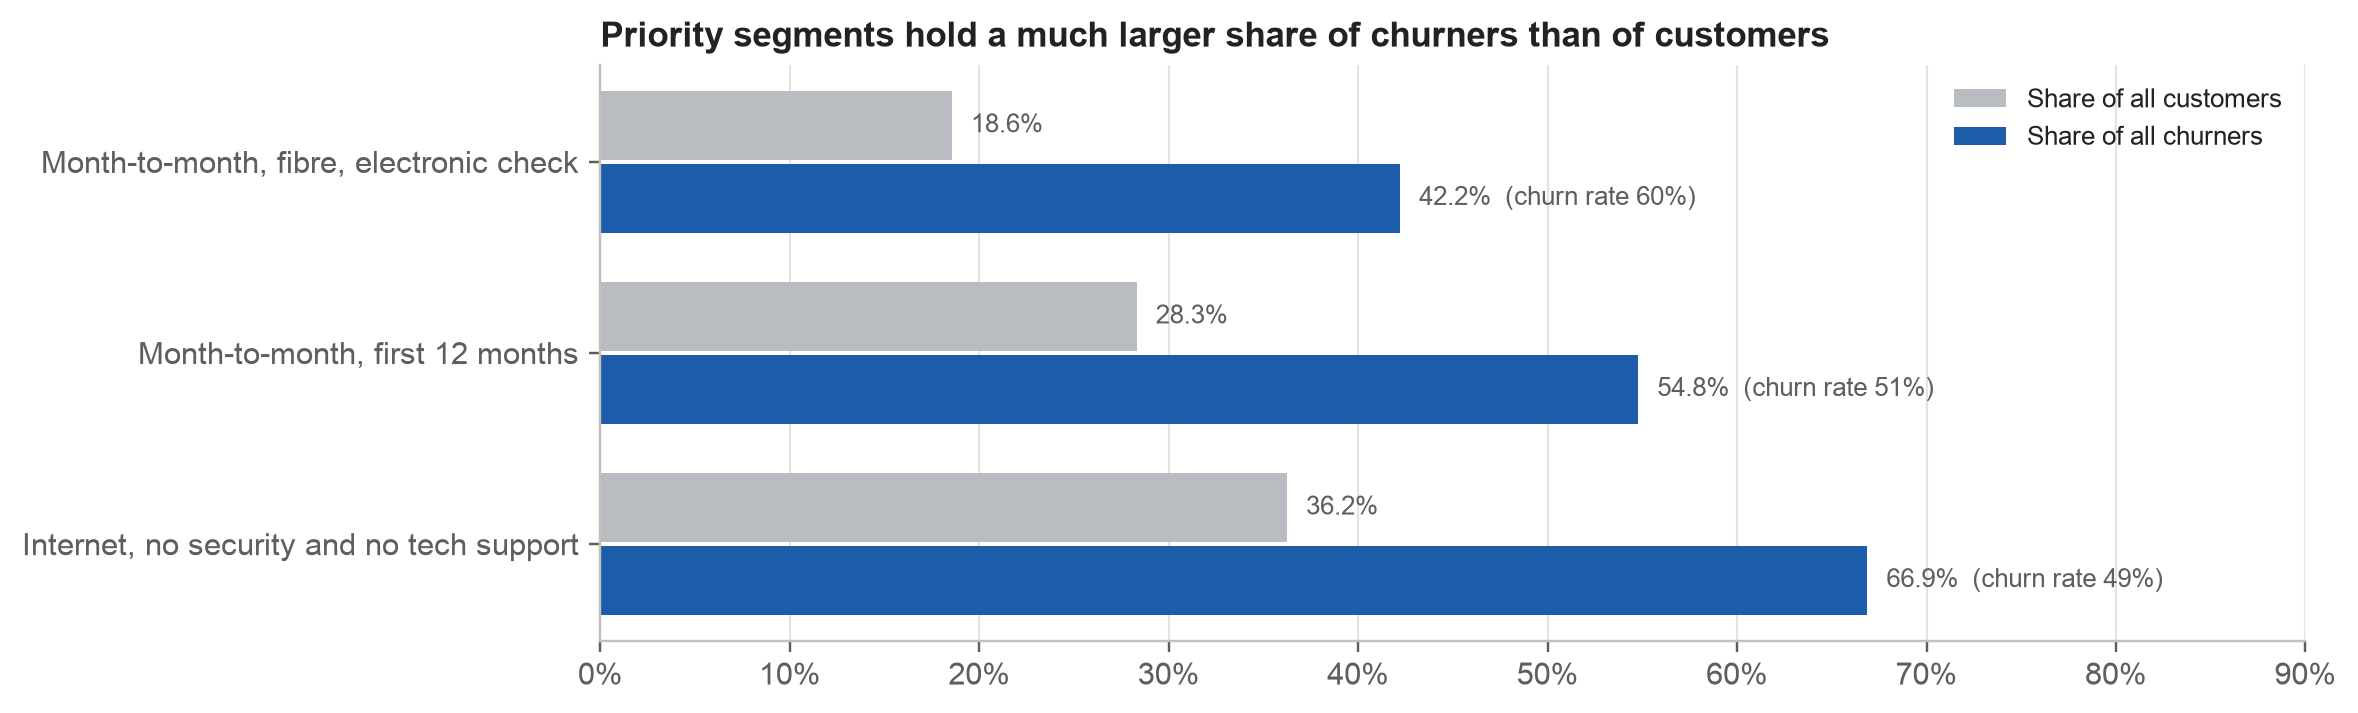

In [10]:
plot_table = segment_table.iloc[:3].iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(plot_table))
ax.barh(y + 0.19, plot_table["share_of_customers"], height=0.36, color=RETAINED_COLOR, label="Share of all customers")
ax.barh(y - 0.19, plot_table["share_of_churners"], height=0.36, color=CHURN_COLOR, label="Share of all churners")
for yy, (_, row) in zip(y, plot_table.iterrows()):
    ax.text(row["share_of_customers"] + 0.01, yy + 0.19, f"{row['share_of_customers']:.1%}", va="center", fontsize=8.5,
            color=MUTED_INK)
    ax.text(row["share_of_churners"] + 0.01, yy - 0.19,
            f"{row['share_of_churners']:.1%}  (churn rate {row['churn_rate']:.0%})", va="center", fontsize=8.5,
            color=MUTED_INK)
ax.set_yticks(y)
ax.set_yticklabels(plot_table["segment"])
ax.set_xlim(0, 0.9)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_title("Priority segments hold a much larger share of churners than of customers")
ax.legend(loc="upper right", fontsize=8.5)
ax.grid(axis="y", visible=False)
save_figure(fig, "fig5_2_priority_segments.png")

In [11]:
with open(RESULTS_DIR / "final_summary.json", "w") as f:
    json.dump(final, f, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Saved outputs/results/final_summary.json")

Saved outputs/results/final_summary.json
